In [57]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
import json
import os

from Encoder import*
from Tools.model_tools import load_configs
from Tools.data_utils import extract_params_from_filename
from Tools.analysis_tools import*
from Tools.database_tools import*
from Tools.mathematical_tools import*

In [58]:
# Percorso del database
decoder_database_path = "decoderDatabase.json"

# Carica tutte le configurazioni disponibili
all_decoder = load_configs(decoder_database_path)

# Visualizza le configurazioni disponibili
for model_name, config in all_decoder.items():
    print(model_name, config)

Prova15Decoder {'decoder_layers': [5, 10, 15, 20, 25, 30], 'latent_dim': 5, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20,15_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-07}}, 'Encoder': 'Prova15'}
Prova15 {'decoder_layers': [5, 10, 15, 20, 25, 30], 'latent_dim': 5, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20,15_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-08}}, 'Encoder': 'Prova15'}
P0-0.1 {'decoder_layers': [5, 10, 15, 20, 25, 30], 'latent_dim': 5, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20,15_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'

### Load a Neural Network:


#### Load a Decoder:

In this section, we will load one of the trained decoders by its name. The configuration file will provide all details about the network. The primary purpose of this notebook is to analyze the ability of a coupled encoder and specialized decoder. However, with some minor modifications, any encoder can be paired with different decoders if the shapes are compatible.


In [59]:
# Scegli un modello specifico
decoder_name = "PaperVAE22"  # Cambia con il nome desiderato
decoder_config = all_decoder.get(decoder_name)

if decoder_config is None:
    raise ValueError(f"Il modello {decoder_name} non esiste nel database.")

print(f"Il decoder è stato allenato con il modello Encoder : {decoder_config["Encoder"]}" )

Il decoder è stato allenato con il modello Encoder : PaperA2


In [60]:
# Percorso al file del decoder salvato
decoder_file_path = os.path.join("Decoder Models", f"{decoder_name}.pth")
decoder, decoder_checkpoint = load_decoder(decoder_file_path, Decoder)

params = extract_params_from_filename(decoder_config["dataset"])
print(f"Parametri del dataset: {params}")
tau = params["tau"]
embedding_dim = params["embedding_dim"]
r = params["r"]

decoder_epoch = decoder_checkpoint['epoch']
decoder_stopped_epoch = decoder_checkpoint['stopped_epoch']
decoder_train_losses = decoder_checkpoint['train_losses']
decoder_val_losses = decoder_checkpoint['val_losses']
decoder_gradient_history = decoder_checkpoint['gradient_history']

Decoder and training info loaded from Decoder Models/PaperVAE22.pth
Parametri del dataset: {'tau': 3, 'embedding_dim': 100, 'r': 20, 'alpha': 0.0, 'beta': 0.0}


/workspaces/Lorenz-Toy/Tools/training_tools.py:452: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(file_path)


#### Load an Encoder:
The following code will load a trained Encoder from the list. Adjust the code line:

 `encoder_name = decoder_config["Encoder"]` 
 
 to the desired name to use a non-default provided encoder.

In [61]:
#Scelta dell'Encoder da concatenare al Decoder selezionato:
encoder_database_path = "encoderDatabase.json"
all_encoders = load_configs(encoder_database_path)

for model_name, config in all_encoders.items():
    print(model_name, config)

encoder_name = decoder_config["Encoder"] # Cambia per cambiare l'encoder concatenato

encoder_config = all_encoders.get(encoder_name)
if encoder_config is None:
    raise ValueError(f"Il modello {decoder_config["Encoder"]} non esiste nel database.")

if encoder_config["latent_dim"] != decoder_config["latent_dim"]:
    raise ValueError("Le dimensioni latenti dell'encoder e del decoder non coincidono.")

print(f" Si è caricato l'Encoder: {encoder_name}")


#Caricamento del modello preallenato dell'encoder
encoder_model_path = "Encoder Models"
encoder_path = os.path.join(encoder_model_path, encoder_name + ".pth")

encoder, encoder_checkpoint = load_encoder(encoder_path, Encoder)

encoder_epoch = encoder_checkpoint['epoch']
encoder_stopped_epoch = encoder_checkpoint['stopped_epoch']
encoder_train_losses = encoder_checkpoint['train_losses']
encoder_val_losses = encoder_checkpoint['val_losses']
recon_losses = encoder_checkpoint['recon_losses']
kld_losses = encoder_checkpoint['kld_losses']
effective_kld_losses = encoder_checkpoint['effective_kld_losses']
beta_values = encoder_checkpoint['beta_values']
encoder_gradient_history = encoder_checkpoint['gradient_history']
H2_1 = encoder_checkpoint['H2_1']
H2_2 = encoder_checkpoint['H2_2']
denormalizing_params = encoder_checkpoint['denormalizing_params']
P = encoder_checkpoint['P']


Prova {'layer_dims': [15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 1.0, 'kl_annealing_epochs': 500, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay5dim20,15_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'CosineAnnealingLR', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 1e-09, 'base_lr': 0.0001, 'max_lr': 0.01, 'step_size_up': 200, 'T_max': 100, 'T_0': 10, 'T_mult': 2, 'eta_min': 0.0001}}}
Prova15 {'layer_dims': [15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 700, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20,15_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 0.0001}}}
P0 {'layer_dims': [1

/workspaces/Lorenz-Toy/Tools/training_tools.py:370: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


In [62]:
batch_size = decoder_config["batch_size"]

train_data = decoder_checkpoint["train_data"]
val_data = decoder_checkpoint["val_data"]

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

total_sample = len(train_data)+len(val_data)
print(f"Numero totale di campioni: {total_sample}")
print(f"Numero di campioni di training: {len(train_data)}")
print(f"Numero di campioni di validazione: {len(val_data)}")

Numero totale di campioni: 3235
Numero di campioni di training: 1941
Numero di campioni di validazione: 1294


### VAE's training stats:

#### Encoder training:
Risultati del training del modello Encoder per la ricostruzione di $y_1(t)$

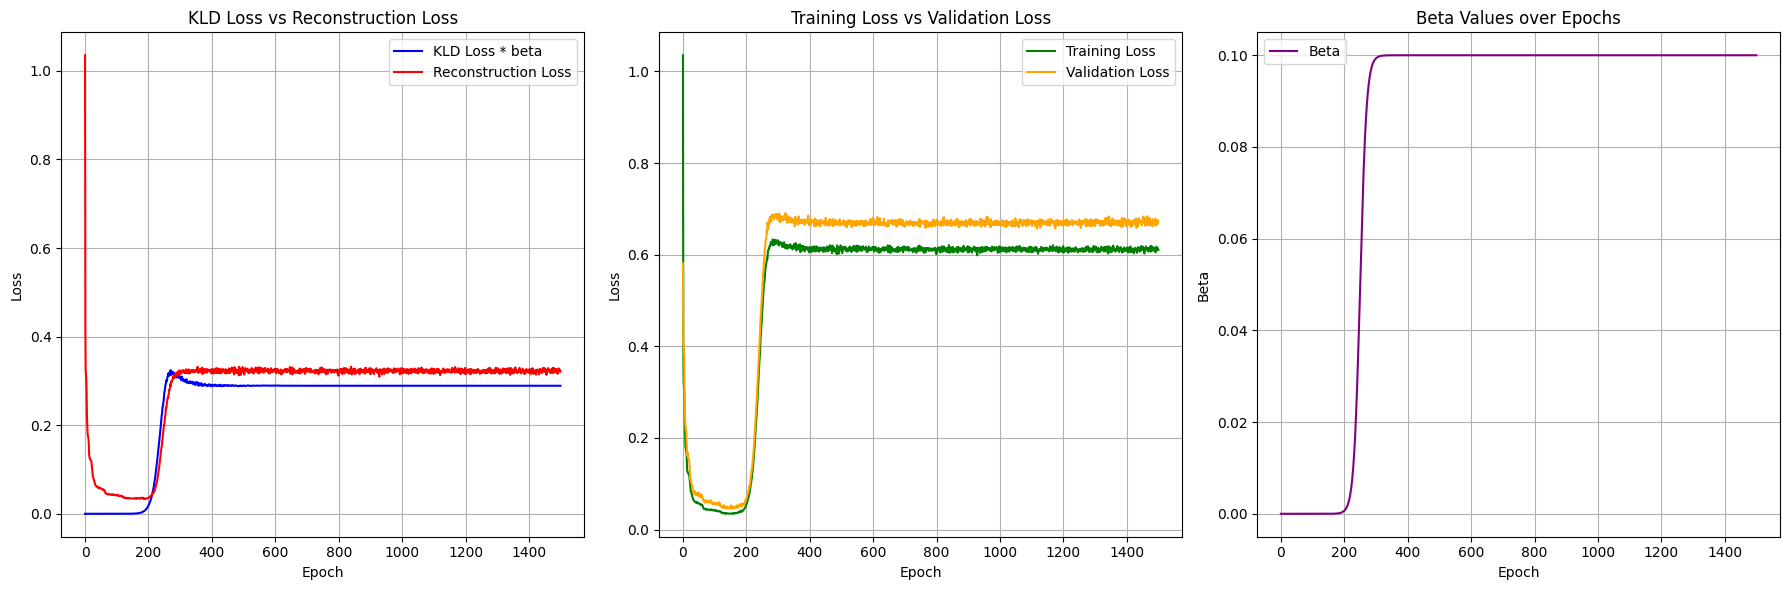

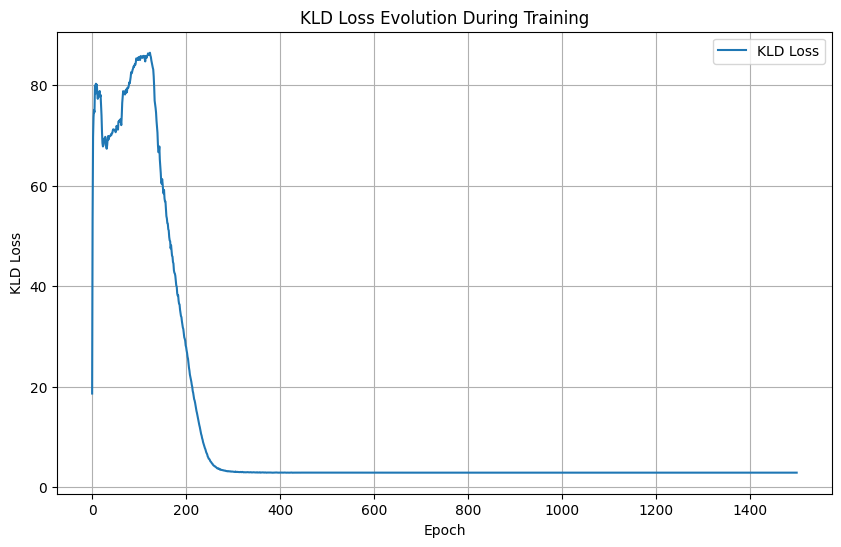

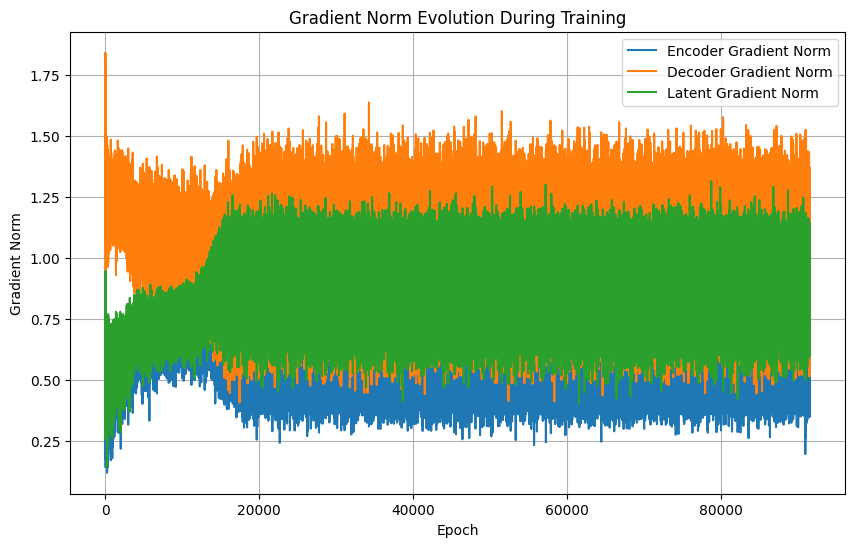

In [63]:
plot_results(encoder_train_losses, encoder_val_losses, recon_losses, kld_losses,effective_kld_losses, beta_values, encoder_gradient_history)

#### Decoder training:
Risultati del training del Decoder per la ricostruzione di $y_2(t)$ dal $y_1(t)$ :

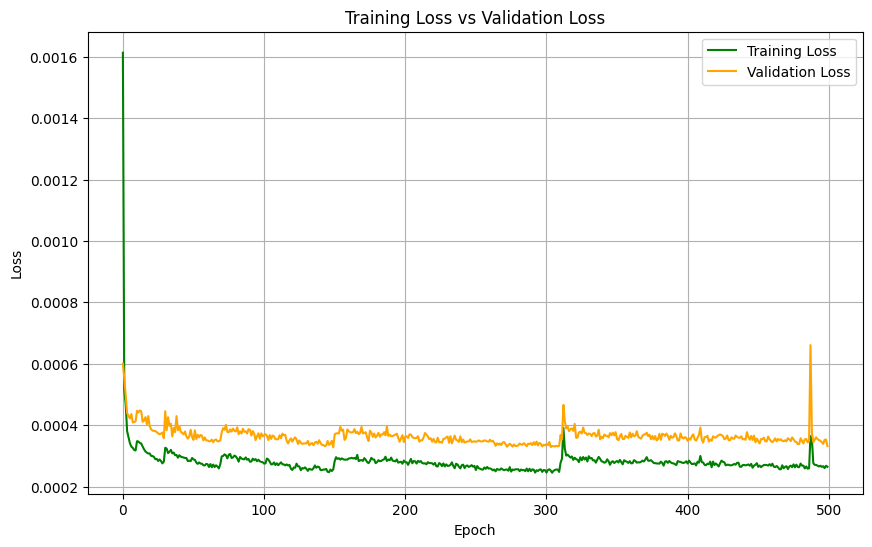

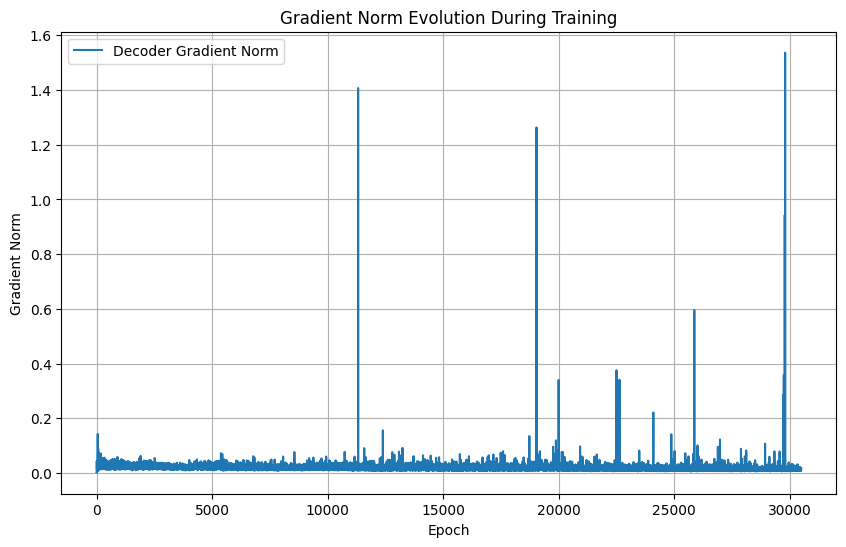

In [64]:
plot_Decoder_results(decoder_train_losses, decoder_val_losses, decoder_gradient_history)

### Validation Dataset:

The validation dataset is processed through the network as implemented in the 'Encoder.py' class and specified in the 'trainDecoder.ipynb' notebook. In this section, we will:

1. Post-process all data to reconstruct dynamics in the original dimensionality.
2. Analyze raw (non post-processed) data reconstruction and post-processed dynamic reconstruction.


In [65]:
# Calling a VAE instance from pre-trained encoder and decoder
vae_model = VAE(encoder, decoder)

# Execute the model on the validation data
input_data, predicted_data, mean_vectors, logvar_vectors = run_model_and_collect_outputs(
    vae_model, val_loader, device="cpu"
)

# Shape print for control
print("Input data shape:", input_data.shape)
print("Predicted data shape:", predicted_data.shape)
print("Mean vectors shape:", mean_vectors.shape)
print("Logvar vectors shape:", logvar_vectors.shape)

# Separation of Z1 and Z3 reduced embeddings from the Network output
reconstructed_y2_1 = predicted_data[:, :r]  # z1 Embedding recon
reconstructed_y2_2 = predicted_data[:, r:]  # z3 Embedding recon

# Reconstruction of projected Hankel Matrices from the Network output
reconstructed_hankel_y2_1 = reconstructed_y2_1.T
reconstructed_hankel_y2_2 = reconstructed_y2_2.T

# Separation of the original data: inputs and targets
inputs, targets = zip(*[val_data[i] for i in range(len(val_data))])

# Conversion of the data into numpy arrays
inputs = torch.stack(inputs).numpy()    # y1 = Z2
targets = torch.stack(targets).numpy()  # y2 = [Z1,Z3]

# Separation of Z1 and Z3 reduced embeddings from the Validation data
original_y2_1 = targets[:, :r]  # z1 Embedding original
original_y2_2 = targets[:, r:]  # z3 Embedding original

# Structure reconstruction of projected Hankel Matrices from the validation data
original_hankel_y2_1 = original_y2_1.T
original_hankel_y2_2 = original_y2_2.T

# Shape print for control
print("Reconstructed Hankel y2_1 shape:", reconstructed_hankel_y2_1.shape)
print("Reconstructed Hankel y2_2 shape:", reconstructed_hankel_y2_2.shape)
print("Original Hankel y2_1 shape:", original_hankel_y2_1.shape)
print("Original Hankel y2_2 shape:", original_hankel_y2_2.shape)

# Aggiunta di ulteriori analisi o confronti, se necessario


Input data shape: (1294, 20)
Predicted data shape: (1294, 40)
Mean vectors shape: (1294, 10)
Logvar vectors shape: (1294, 10)
Reconstructed Hankel y2_1 shape: (20, 1294)
Reconstructed Hankel y2_2 shape: (20, 1294)
Original Hankel y2_1 shape: (20, 1294)
Original Hankel y2_2 shape: (20, 1294)


Varianza spiegata: [0.33170578 0.2320778 ]


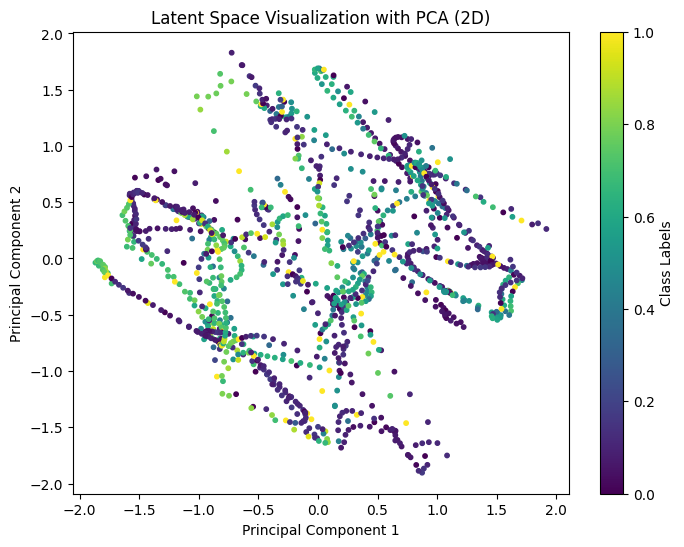

In [66]:
# Esegui la visualizzazione
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
visualize_latent_space_with_pca(vae_model, val_data, device=device, n_components=2)

#### Recovering Dimensionality:

Here is the code to revert the preprocessing of the data and create variables for later analysis. The steps to follow are three and are coherent with the preprocessing: reconstruct the Hankel matrix from projected delay vectors, denormalize the matrix, and revert the projection from the Legendre basis.

##### Post-processing:

\( p = 260 \) for the validation dataset  
\( d = 20 \) (embedding dimension)

Hankel Matrix: <br>

$
H(t) =
\begin{bmatrix}
y(t_1) & y(t_2) & y(t_3) & \cdots & y(t_{p-d+1}) \\
y(t_2) & y(t_3) & y(t_4) & \cdots & y(t_{p-d+2}) \\
y(t_3) & y(t_4) & y(t_5) & \cdots & y(t_{p-d+3}) \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
y(t_d) & y(t_{d+1}) & y(t_{d+2}) & \cdots & y(t_p)
\end{bmatrix}
\in \mathbb{R}^{d \times (p-d+1)}
$

Legendre Basis Matrix: <br>

$ 
P^{(r)} = 
\begin{bmatrix}
P_0(x_0) & P_1(x_0) & \cdots & P_r(x_0) \\
P_0(x_1) & P_1(x_1) & \cdots & P_r(x_1) \\
P_0(x_2) & P_1(x_2) & \cdots & P_r(x_2) \\
\vdots & \vdots & \ddots & \vdots \\
P_0(x_{d-1}) & P_1(x_{d-1}) & \cdots & P_r(x_{d-1})
\end{bmatrix}
\in \mathbb{R}^{d \times r}
$

Projection of Hankel into Legendre Polynomial Basis:

$
Y^T = H^T \cdot P^{(r)} \in \mathbb{R}^{(p-d+1) \times r} 
$

So we perform:

$
H^T = Y^T \cdot P^{\dagger}
$

where $P^{\dagger}$ is the pseudo-inverse of  $P$.


In [67]:
from numpy.linalg import pinv

# Validation data indices
validation_indices = val_data.indices

# Original (non projected) Hankel matrices of y2
H2_1_data = H2_1[:, validation_indices] # Z1
H2_2_data = H2_2[:, validation_indices] # Z3

# Denormalization of the projected Hankel matrices
validation_min_vals_1 = denormalizing_params["min_h2_1"][:, validation_indices]
validation_max_vals_1 = denormalizing_params["max_h2_1"][:, validation_indices]
validation_min_vals_2 = denormalizing_params["min_h2_2"][:, validation_indices]
validation_max_vals_2 = denormalizing_params["max_h2_2"][:, validation_indices]

reconstructed_hankel_y2_1 = denormalize_columns(reconstructed_hankel_y2_1, validation_min_vals_1, validation_max_vals_1)
reconstructed_hankel_y2_2 = denormalize_columns(reconstructed_hankel_y2_2, validation_min_vals_2, validation_max_vals_2)

# Pseudo-inverse of the Legendre Basis Matrix 
P_pseudo_inverse = pinv(P)

# Shape check
print("Legendre Basis Matrix Shape (d x r):" , P.shape)
print("Pseudo-inverse of P shape (r x d):", P_pseudo_inverse.shape)
print("Input data Matrix shape (y1):", inputs.T.shape)
print("Predicted data Matrix shape (y2):")
print("Reconstructed Hankel y2_1 shape:", reconstructed_hankel_y2_1.shape)
print("Reconstructed Hankel y2_2 shape:", reconstructed_hankel_y2_2.shape)

# Reverse projection of the predicted Matrix using pseudo-inverse of P
recon_H2_1 = np.dot(reconstructed_hankel_y2_1.T, P_pseudo_inverse) 
recon_H2_2 = np.dot(reconstructed_hankel_y2_2.T, P_pseudo_inverse)

recon_H2_1 = recon_H2_1.T
recon_H2_2 = recon_H2_2.T

print("Predicted Reconstructed Hankel shape:", recon_H2_1.shape)
print("Predicted Reconstructed Hankel shape:", recon_H2_2.shape)


Legendre Basis Matrix Shape (d x r): (100, 20)
Pseudo-inverse of P shape (r x d): (20, 100)
Input data Matrix shape (y1): (20, 1294)
Predicted data Matrix shape (y2):
Reconstructed Hankel y2_1 shape: (20, 1294)
Reconstructed Hankel y2_2 shape: (20, 1294)
Predicted Reconstructed Hankel shape: (100, 1294)
Predicted Reconstructed Hankel shape: (100, 1294)


#### Analysis of the Network Output:
We will analyze the performance of the VAE on the direct reconstruction of the input. That means that there will be no post-process (dimensionality increase) in the data and metrics such as MSE and $R^2$ will be used.

r2_score entries: 1294
r2_score entries: 1294
Indices of the 3 samples with the worst R² (z1): [1019   35 1050]
Mean R² for Z1 recon: 0.6123016 pm 0.38637024
Indices of the 3 samples with the worst R² (z2): [940 728 843]
Mean R² for Z3 recon: 0.033286504 pm 0.24561417


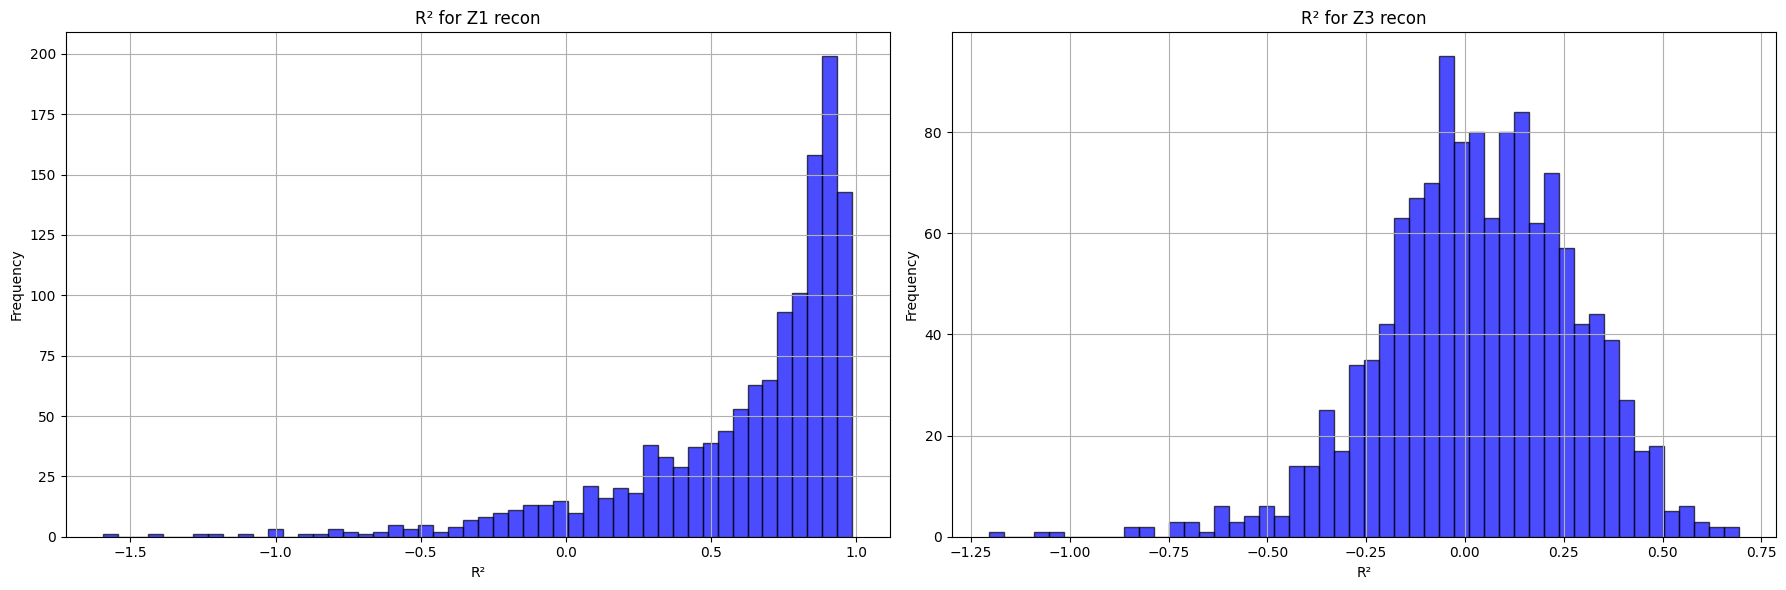

In [68]:
# Plot the R² histogram and get the indices of the worst R² samples
worst_r2_indices1, r2_scores1 = plot_r2_histogram(original_y2_1,reconstructed_y2_1)
mean_r21 = np.mean(r2_scores1)
std_r21 = np.std(r2_scores1)

worst_r2_indices2, r2_scores2 = plot_r2_histogram(original_y2_2,reconstructed_y2_2)
mean_r22 = np.mean(r2_scores2)
std_r22 = np.std(r2_scores2)


fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot R² histogram for Z1 recon
axes[0].hist(r2_scores1, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('R² for Z1 recon')
axes[0].set_xlabel('R²')
axes[0].set_ylabel('Frequency')
axes[0].grid(True)

print("Indices of the 3 samples with the worst R² (z1):", worst_r2_indices1)
print("Mean R² for Z1 recon:", mean_r21 , "pm", std_r21)

# Plot R² histogram for Z3 recon
axes[1].hist(r2_scores2, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[1].set_title('R² for Z3 recon')
axes[1].set_xlabel('R²')
axes[1].set_ylabel('Frequency')
axes[1].grid(True)

print("Indices of the 3 samples with the worst R² (z2):", worst_r2_indices2)
print("Mean R² for Z3 recon:", mean_r22 , "pm", std_r22)

plt.tight_layout()
plt.show()

Entries: 1294


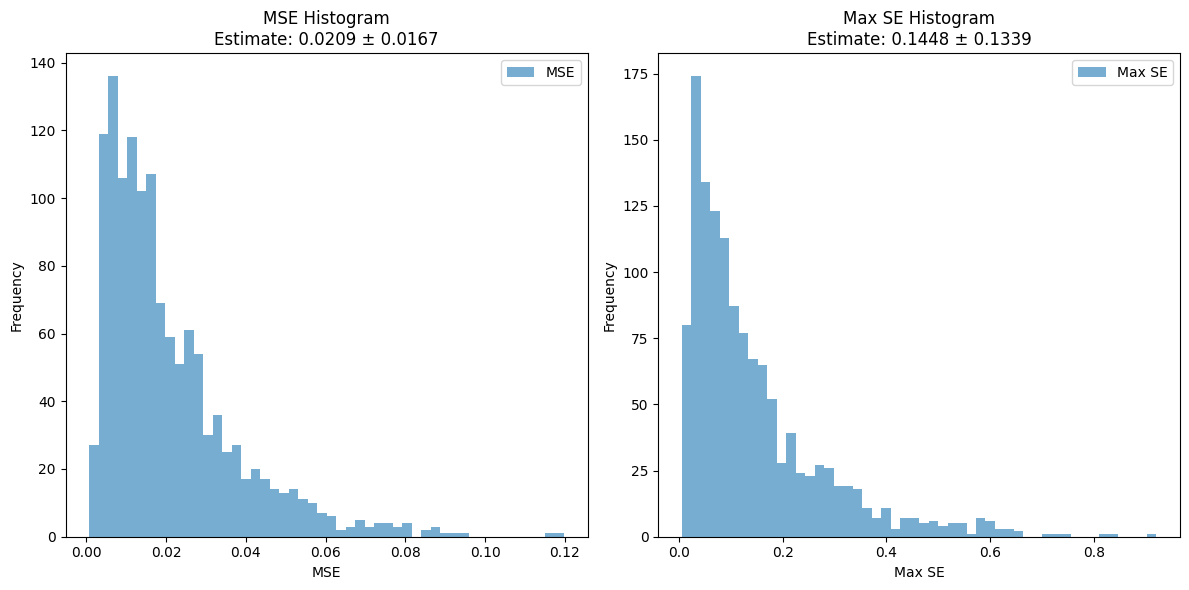

Indices of the 3 samples with the worst MAXse: [1019 1056   35]
Mean MSE for Z1 recon: 0.020858936 pm 0.01674712
Mean MAXse for Z1 recon: 0.14481667 pm 0.13387345
Entries: 1294


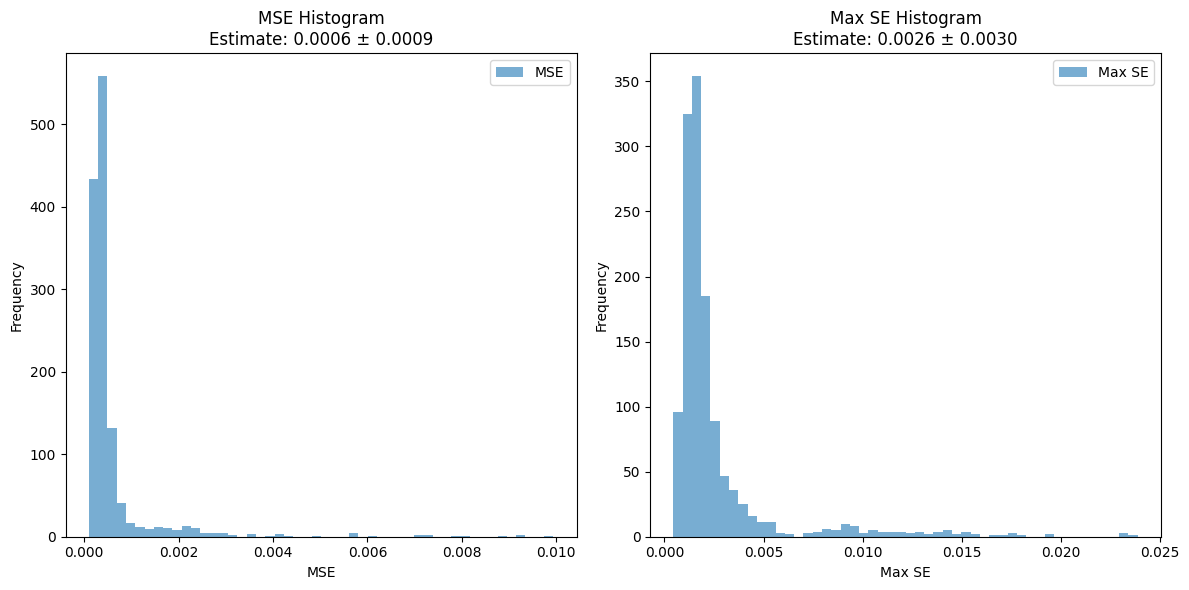

Indices of the 3 samples with the worst MAXse: [21 97 95]
Mean MSE for Z3 recon: 0.00058024476 pm 0.0009243518
Mean MAXse for Z3 recon: 0.0025784646 pm 0.0029844255


In [69]:
# Calculate errors and plot histogram for Z1 recon
worst_max_se_indices1, best_mse_indices1, mse_errors1, max_se_errors1 = calculate_errors_and_plot_hist(original_y2_1, reconstructed_y2_1)
mean_mse = mse_errors1.mean()
std_mse = mse_errors1.std()
mean_max_se = max_se_errors1.mean()
std_max_se = max_se_errors1.std()
print("Indices of the 3 samples with the worst MAXse:", worst_max_se_indices1)

print("Mean MSE for Z1 recon:", mean_mse , "pm", std_mse)
print("Mean MAXse for Z1 recon:", mean_max_se , "pm", std_max_se)

# Calculate errors and plot histogram for Z3 recon
worst_max_se_indices2, best_mse_indices2, mse_errors2, max_se_errors2 = calculate_errors_and_plot_hist(original_y2_2, reconstructed_y2_2)
mean_mse2 = mse_errors2.mean()
std_mse2 = mse_errors2.std()
mean_max_se2 = max_se_errors2.mean()
std_max_se2 = max_se_errors2.std()
print("Indices of the 3 samples with the worst MAXse:", worst_max_se_indices2)

print("Mean MSE for Z3 recon:", mean_mse2 , "pm", std_mse2)
print("Mean MAXse for Z3 recon:", mean_max_se2 , "pm", std_max_se2)

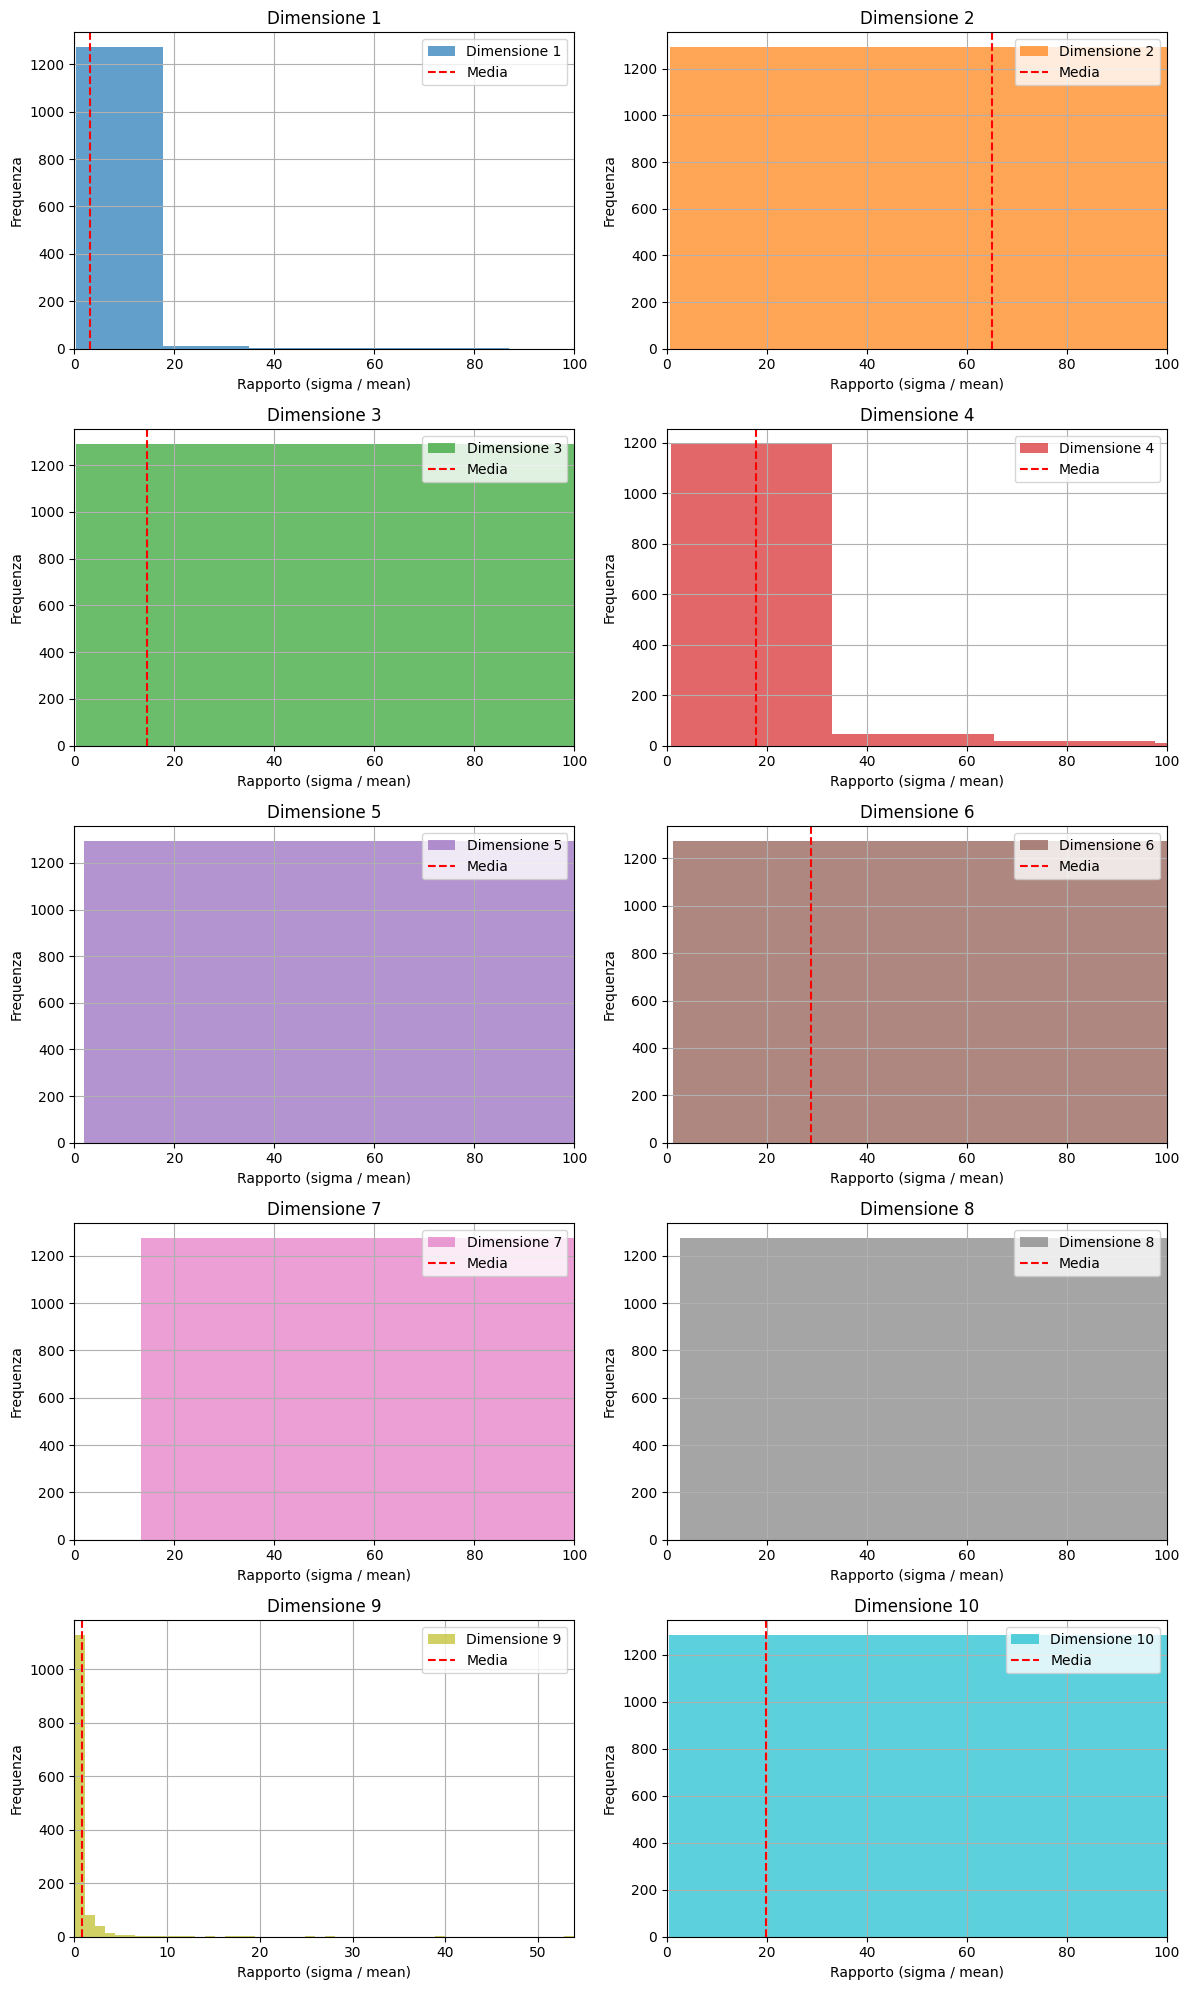

In [70]:
latent_variables(vae_model,mean_vectors,logvar_vectors,val_loader,'cpu')

#### Time series reconstruction: $y_2(t) =[Z_1(t),Z_3(t)]^T + \beta \cdot \sigma$:

Now we can reconstruct the predicted time series of $y_i(t)$ using the Hankel Matrix obtained after the reverse projection of the VAE's output.
We can use tha fact that H is of the form:

$ H =
\begin{bmatrix}
y_i(t_1) & y_i(t_2) & y_i(t_3) & \cdots & y_i(t_(p-d+1)) \\
y_i(t_2) & y_i(t_3) & y_i(t_4) & \cdots & y_i(t+n) \\
y_i(t_3) & y_i(t_4) & y_i(t_5) & \cdots & y_i(t+n+1) \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
y_i(t_d) & y_i(t_(d+1)) & y_i(t_(d+2)) & \cdots & y_i(t_p)
\end{bmatrix}
 \in \mathbb{R}^{d \times (p-d+1)}
$

so the time series: $ y_i(t) = \{ y_i(t_1) , y_i(t_2), ... y_i(t_p)  \} = $ diagMean($H$) 

It's important to note that this process of reversing the projection from the legendre polynomial basis introduce additional noise in the data.


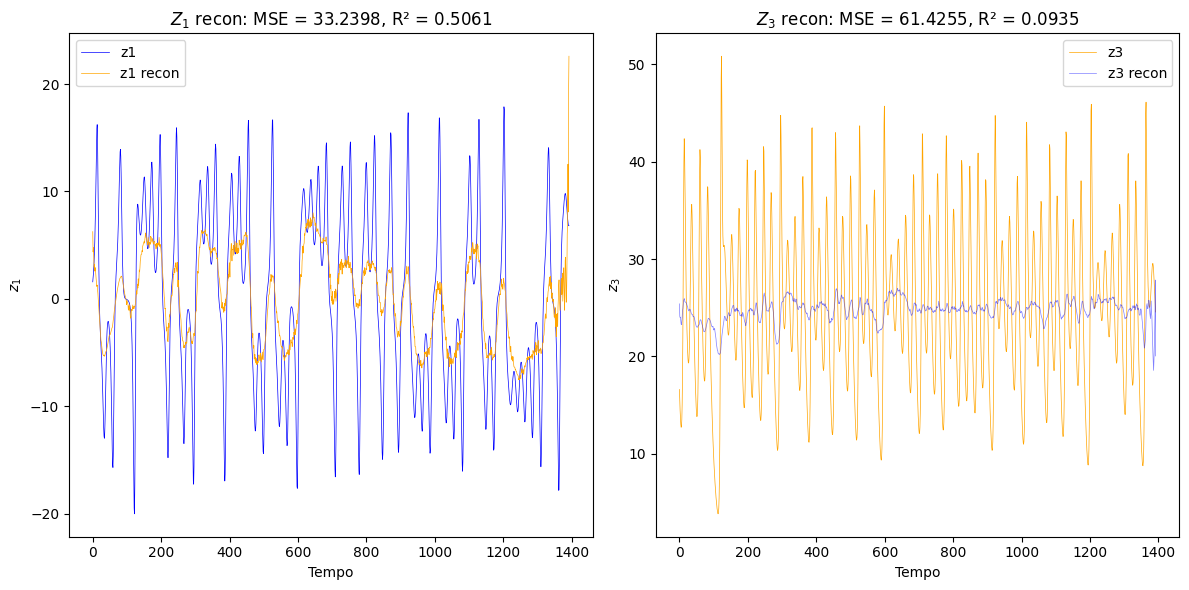

In [71]:
# Ricostruzione di Z1 dal suo embedding (Validation data)
val_Z1 = reconstruct_time_series(H2_1_data)
#Ricostruzione da Z3 dal suo embedding (Validation data)
val_Z3 = reconstruct_time_series(H2_2_data)


recon_Z1 = reconstruct_time_series(recon_H2_1)
recon_Z3 = reconstruct_time_series(recon_H2_2)


val_Z2 = reconstruct_time_series(inputs.T)

# Calcola l'errore quadratico medio
mse1 = np.mean((val_Z1 - recon_Z1) ** 2)
mse2 = np.mean((val_Z3 - recon_Z3) ** 2)

# Calcolo R2:

r2_1 = r2_score(val_Z1, recon_Z1)
r2_2 = r2_score(val_Z3, recon_Z3)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Segnale y2(1)
axes[0].plot(val_Z1, label="z1", color='blue', lw=0.5)
axes[0].plot(recon_Z1, label="z1 recon", color='orange', lw=0.5)
axes[0].legend()
axes[0].set_title(r"$Z_1$ recon: MSE = {:.4f}, R² = {:.4f}".format(mse1, r2_1))
axes[0].set_xlabel("Tempo")
axes[0].set_ylabel("$z_1$")

# Segnale y2(2)
axes[1].plot(val_Z3, label="z3", color='orange', lw=0.5)
axes[1].plot(recon_Z3, label="z3 recon", color='blue', alpha=0.5, lw=0.5)
axes[1].legend()
axes[1].set_title(r"$Z_3$ recon: MSE = {:.4f}, R² = {:.4f}".format(mse2, r2_2))
axes[1].set_xlabel("Tempo")
axes[1].set_ylabel("$z_3$")

plt.tight_layout()
plt.show()

### PC's reconstruction:
In this section, we will analyze the VAE's ability to reconstruct the principal components (PCs) of the system under study and the network's ability to extract and explain variation in data.

In [72]:
def plot_temporal_signal_and_pcs(original_signal, original_embeddings, reconstructed_embeddings, n_components=3):
    """
    Plotta il segnale temporale originale, le PC calcolate dagli embedding originali,
    e le PC ricostruite dagli embedding di output della rete per ogni componente principale.
    
    Parameters:
        original_signal (np.ndarray): Segnale temporale originale (1D array).
        original_embeddings (np.ndarray): Embedding del segnale originale (2D array).
        reconstructed_embeddings (np.ndarray): Embedding ricostruito dalla rete (2D array).
        n_components (int): Numero di componenti principali da calcolare.
    """
    # PCA sugli embedding originali
    pca = PCA(n_components=n_components)
    pc_original = pca.fit_transform(original_embeddings)  # Tutte le PC dagli embedding originali
    pc_reconstructed = pca.transform(reconstructed_embeddings)  # Proiezione delle PC ricostruite

    # Plot per ogni componente principale
    for i in range(n_components):
        # Calcola R^2 tra la PC originale e quella ricostruita
        r2 = r2_score(pc_original[:, i], pc_reconstructed[:, i])

        # Plot
        plt.figure(figsize=(12, 6))
        #plt.plot(original_signal, label='Input signal', color='black', lw=1.5)
        plt.plot(pc_original[:, i], label=f'PC{i+1} ', color='orange', lw=1.5)
        plt.plot(pc_reconstructed[:, i], label=f'PC{i+1} recon', linestyle='--', color='blue', alpha=0.7, lw=1.5)
        plt.title(f"Confronto tra Segnale Temporale e PC{i+1} Ricostruite - $R^2$: {r2:.2f}")
        plt.xlabel("Time (t)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.show()


#### $y_1(t)$ PC's reconstruction:

##### PC's from $y_2^{(1)} = Z_1(t) + \beta \cdot \sigma$ :

Principal Component Analysis (PCA) is performed on the projected Hankel matrix relative to the observable $y_1(t)$, which serves as the network input. Subsequently, the predicted reduced Hankel matrix relative to the observable $Z_1(t)$ is projected into the input PCs, and the $R^2$ coefficient is evaluated to quantify the quality of the reconstruction.


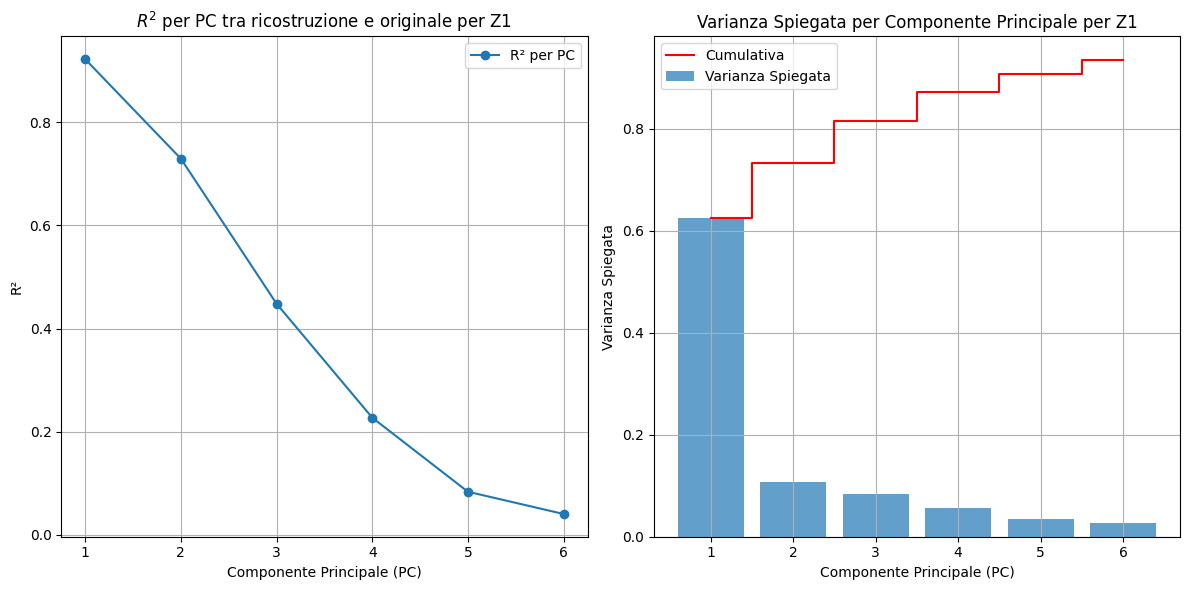

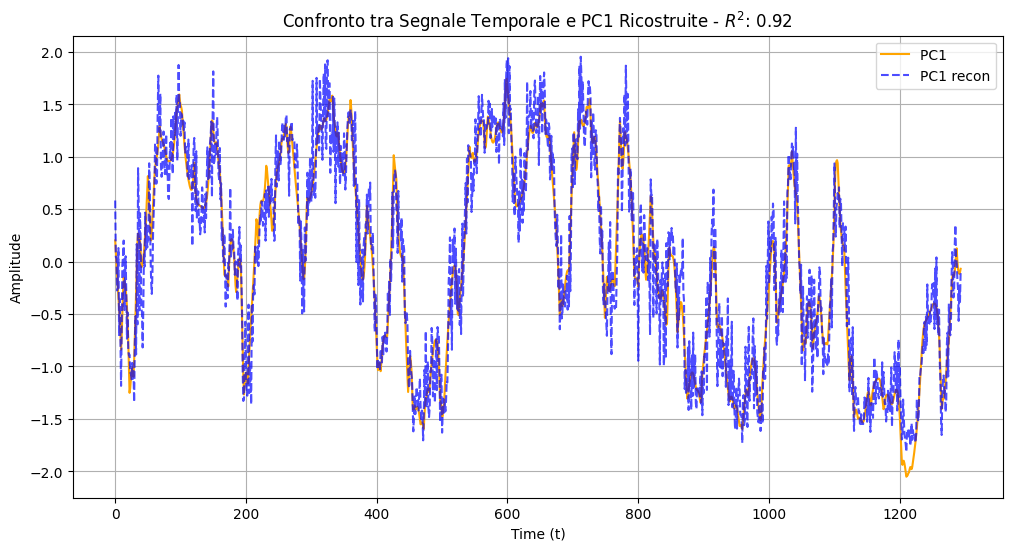

In [73]:
# Confronta PC per Z1
title1 = f"$R^2$ per PC tra ricostruzione e originale per Z1"
title2 = f"Varianza Spiegata per Componente Principale per Z1"
r2_z1, ind2 = pca_r2_analysis_embeddings(inputs, reconstructed_y2_1, title1, title2, n_components=6)
plot_temporal_signal_and_pcs(val_Z2, inputs, reconstructed_y2_1,n_components=1)  

##### PC's from $y_2^{(2)} = Z_3(t) + \beta \cdot \sigma$ :
As explained in the previous cell, we will perform a similar analysis for the observable $Z_3(t)$. This involves projecting the Hankel matrix associated with $y_1(t)$ into the principal components (PCs) and subsequently evaluating the $R^2$ coefficient to assess the quality of the reconstruction.


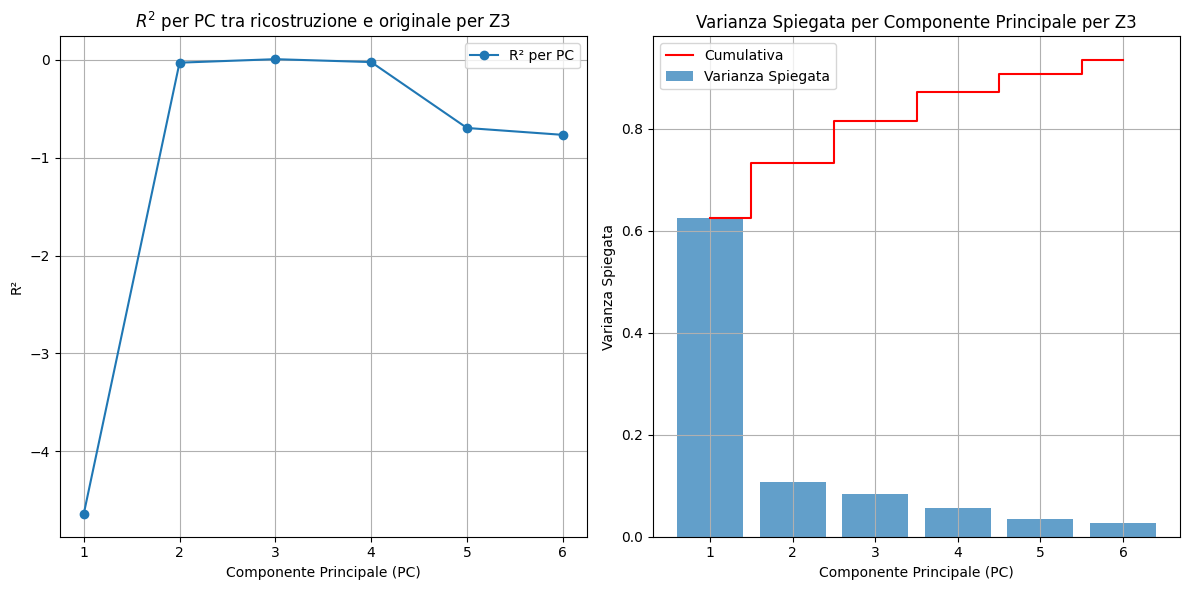

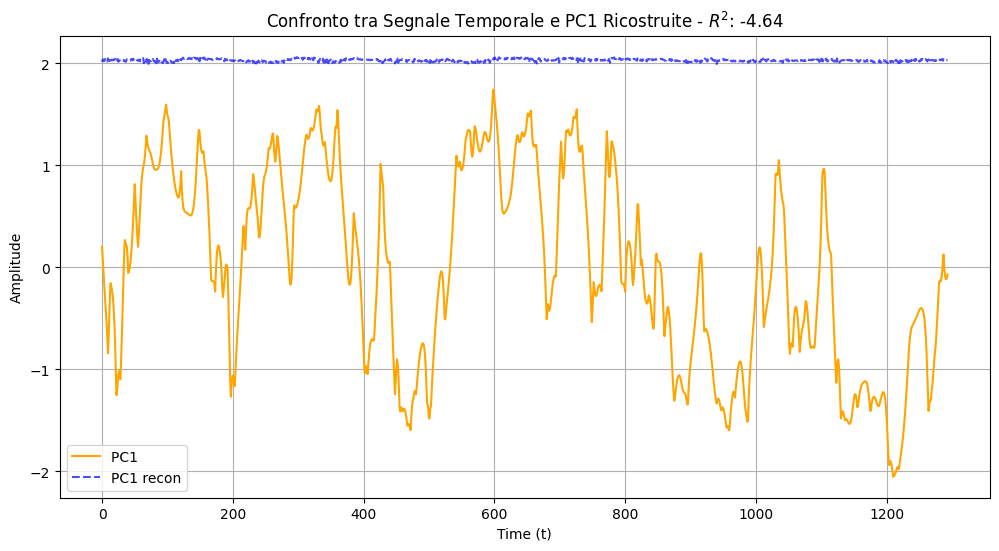

In [74]:
# Confronta PC per Z2
title1 = f"$R^2$ per PC tra ricostruzione e originale per Z3"
title2 = f"Varianza Spiegata per Componente Principale per Z3"
r2_z2, ind3 = pca_r2_analysis_embeddings(inputs, reconstructed_y2_2,title1,title2, n_components=6)
plot_temporal_signal_and_pcs(val_Z2, inputs, reconstructed_y2_2,n_components=1) 

#### $y_2(t)$ PC's reconstruction:
Principal Component Analysis (PCA) is performed on the projected Hankel matrix relative to the observable $y_2^{(i)}(t)$, which is known as it is given information in the validation dataset. Subsequently, the predicted reduced Hankel matrix relative to the reconstructed observable $Z_i(t)$ is projected into the previously found PCs, and the $R^2$ coefficient is evaluated to quantify the quality of the reconstruction.

##### PC's from $y_2^{(1)} = Z_1(t) + \beta \cdot \sigma$ :

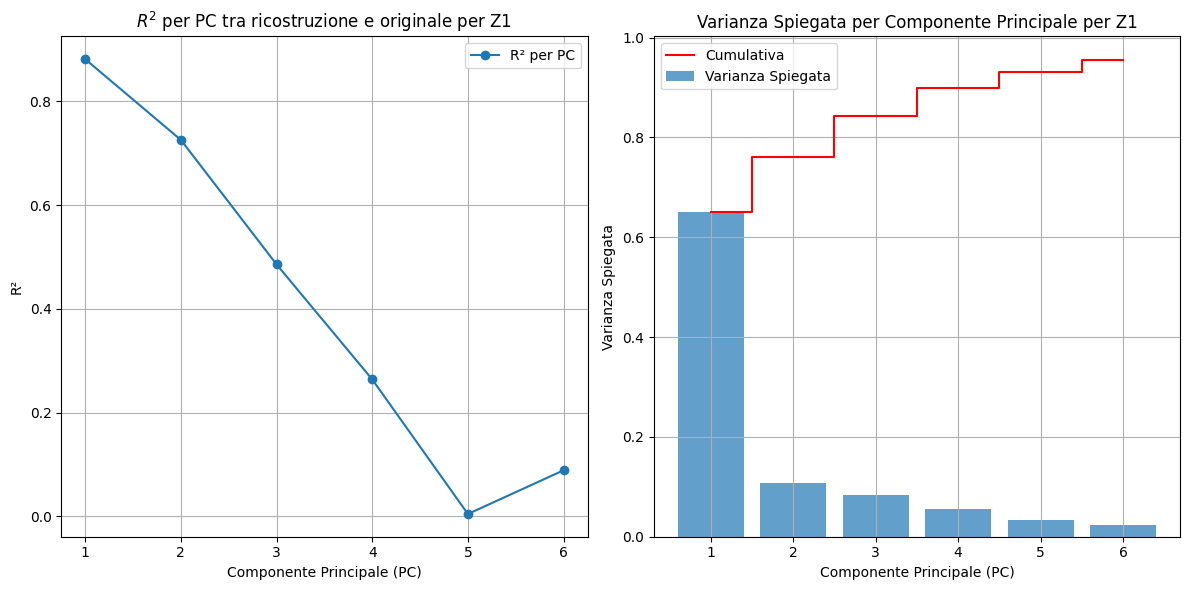

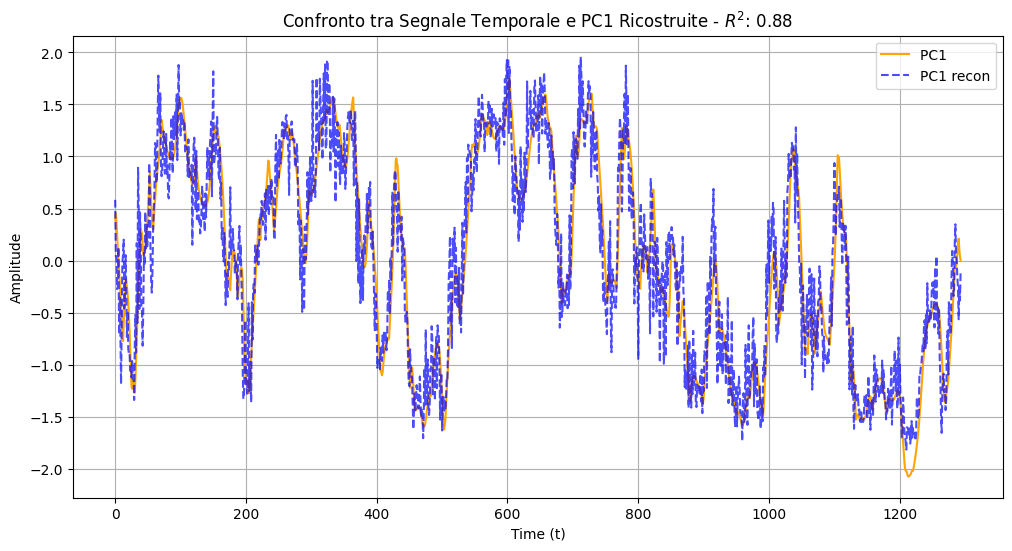

In [75]:
title1 = f"$R^2$ per PC tra ricostruzione e originale per Z1"
title2 = f"Varianza Spiegata per Componente Principale per Z1"
_, _ = pca_r2_analysis_embeddings(original_y2_1, reconstructed_y2_1,title1,title2, n_components=6)
plot_temporal_signal_and_pcs(val_Z3, original_y2_1,reconstructed_y2_1, n_components=1)

##### PC's from $y_2^{(2)} = Z_3(t) + \beta \cdot \sigma$ :

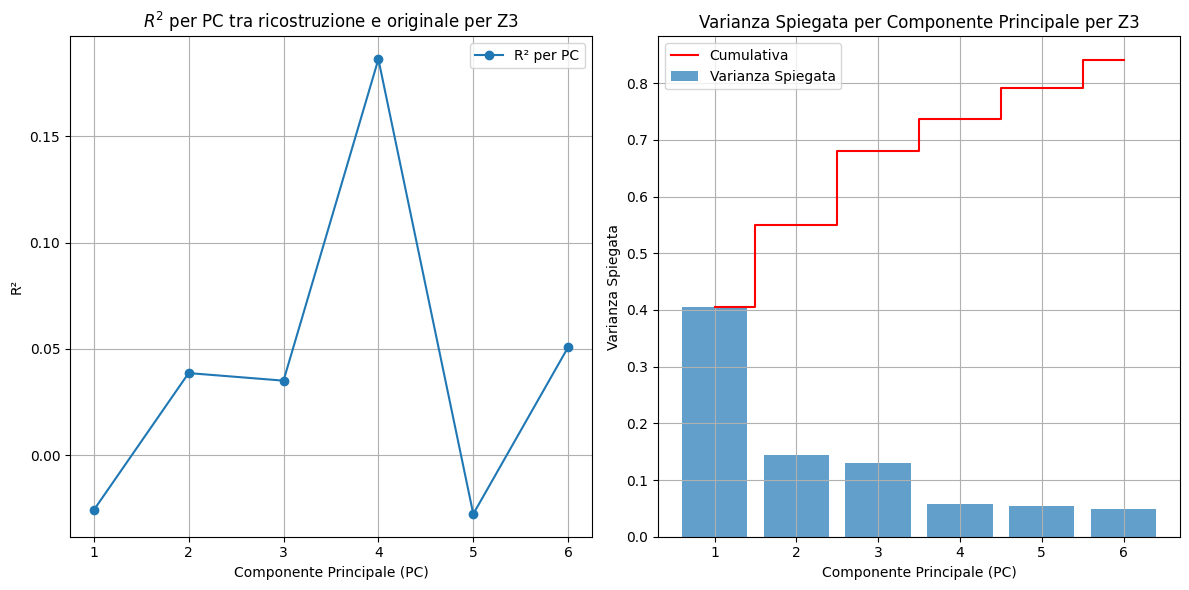

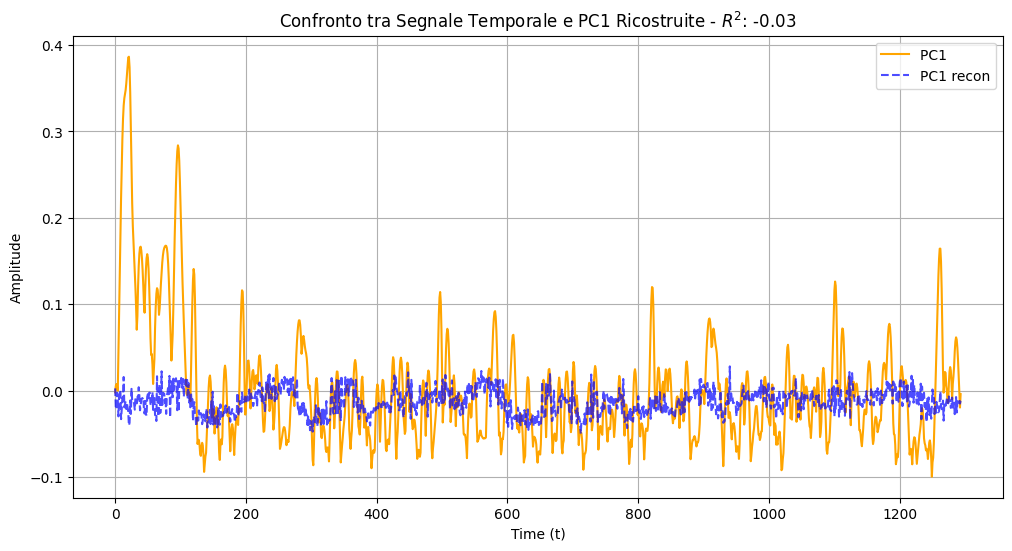

In [76]:
title1 = f"$R^2$ per PC tra ricostruzione e originale per Z3"
title2 = f"Varianza Spiegata per Componente Principale per Z3"
_, _ = pca_r2_analysis_embeddings(original_y2_2, reconstructed_y2_2,title1,title2, n_components=6)
plot_temporal_signal_and_pcs(val_Z3, original_y2_2,reconstructed_y2_2, n_components=1)

#### 2- Ricostruzione delle PC di $y_2(t)$ dagli embedding di $Z_1,Z_3$

In questo grafico analizziamo la capacità della rete di ricostruire le PC dei veri dati che la rete dovrebbe restituire.
Per le componenti di $y_2(t) = [Z_1,Z_3]^T + \beta \cdot \sigma$ costruiamo dai dati originali le matrici contenenti gli embedding. Poi uniamo le due matrici contenenti gli embedding delle variabili $[Z_1,Z_3]$ ottenendo una Matrice con shape (n_samples, 2* embedding dim ) in cui sono concatenati gli embedding delle due variabili e in seguito. Si usa poi su questi PCA.fit per calcolare media e varianza delle componenti principali e transform per ridurre la dimensionalità dei dati originali e plottare la componente principale come un segnale temporale.
Si applica poi la trasformazione sugli output della rete combinati allo stesso modo proiettandoli sulle componenti principali dei dati di reali.
Si calcola poi l'indice $R^2$ per analizzare la varianza tra la PC# ottenuta dai dati originali e la proiezione dei dati di output sulle stesse componenti.


In [77]:
def plot_pca_comparison_combined(original_signal, original_embeddings_z1, original_embeddings_z3, reconstructed_embeddings_z1, reconstructed_embeddings_z3, n_components=3):
    """
    Confronta il segnale temporale originale, le PC calcolate dagli embedding originali combinati,
    e le PC ricostruite combinando gli embedding di output della rete per \( Z1 \) e \( Z3 \).
    
    Parameters:
        original_signal (np.ndarray): Segnale temporale originale (1D array).
        original_embeddings_z1 (np.ndarray): Embedding originale di \( Z1 \) (2D array).
        original_embeddings_z3 (np.ndarray): Embedding originale di \( Z3 \) (2D array).
        reconstructed_embeddings_z1 (np.ndarray): Embedding ricostruito dalla rete per \( Z1 \) (2D array).
        reconstructed_embeddings_z3 (np.ndarray): Embedding ricostruito dalla rete per \( Z3 \) (2D array).
        n_components (int): Numero di componenti principali da calcolare.
    """
    # Combina gli embedding originali di Z1 e Z3
    original_embeddings_combined = np.hstack([original_embeddings_z1, original_embeddings_z3])
    # Combina gli embedding ricostruiti di Z1 e Z3
    reconstructed_embeddings_combined = np.hstack([reconstructed_embeddings_z1, reconstructed_embeddings_z3])

    # PCA sugli embedding combinati originali
    pca = PCA(n_components=n_components)
    pc_original = pca.fit_transform(original_embeddings_combined)  # Tutte le PC dagli embedding originali combinati
    pc_reconstructed = pca.transform(reconstructed_embeddings_combined)  # Proiezione delle PC combinate ricostruite

    # Plot per ogni componente principale
    for i in range(n_components):
        # Calcola R^2 tra la PC originale e quella ricostruita
        r2 = r2_score(pc_original[:, i], pc_reconstructed[:, i])

        # Plot
        plt.figure(figsize=(12, 6))
        #plt.plot(original_signal, label='Input signal', color='black', lw=1.5)
        plt.plot(pc_original[:, i], label=f'PC{i+1}', color='orange', lw=1.5)
        plt.plot(pc_reconstructed[:, i], label=f'PC{i+1} recon', linestyle='--', color='blue', alpha=0.7, lw=1.5)
        plt.title(f"Confronto tra Segnale Temporale e PC{i+1} Ricostruite (Z1+Z3) - $R^2$: {r2:.2f}")
        plt.xlabel("Time (t)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.show()


<>:2: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_14542/1287100422.py:2: SyntaxWarning: invalid escape sequence '\('
  """


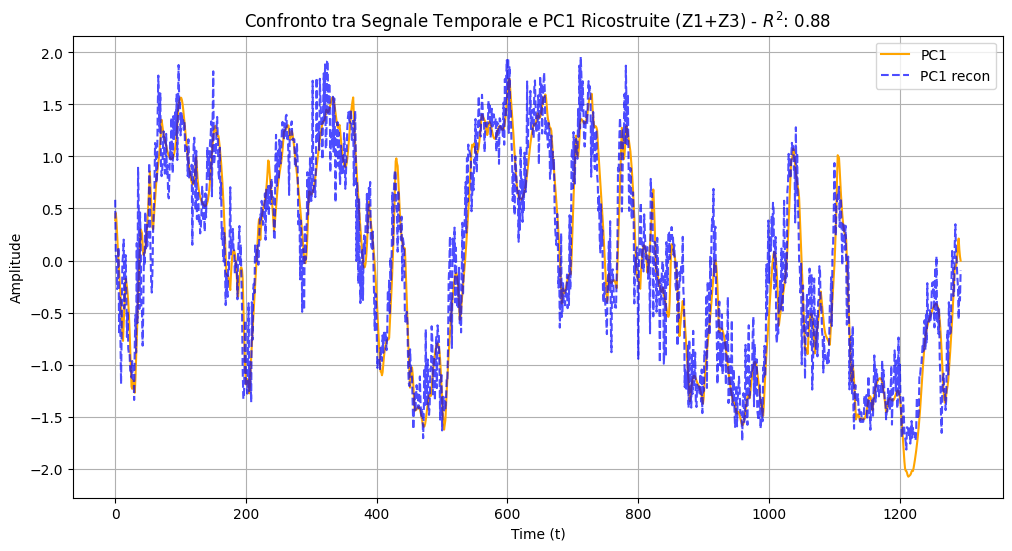

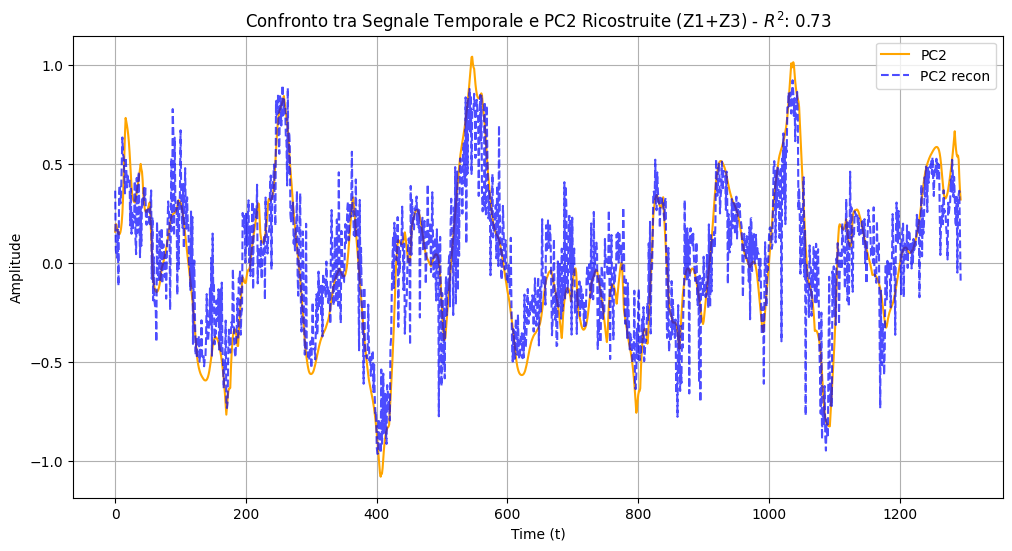

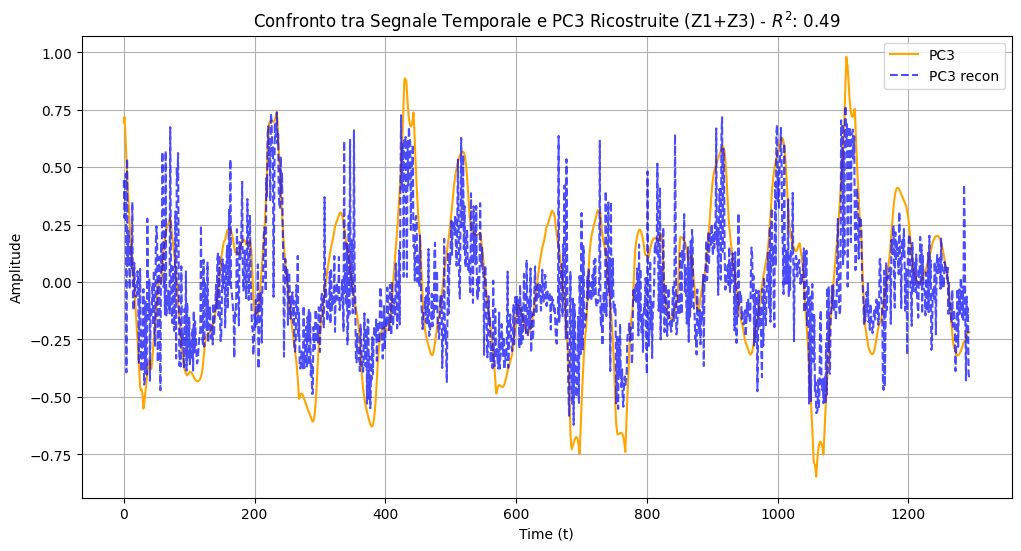

In [78]:
plot_pca_comparison_combined(val_Z2, original_y2_1, original_y2_2, reconstructed_y2_1, reconstructed_y2_2, n_components=3)

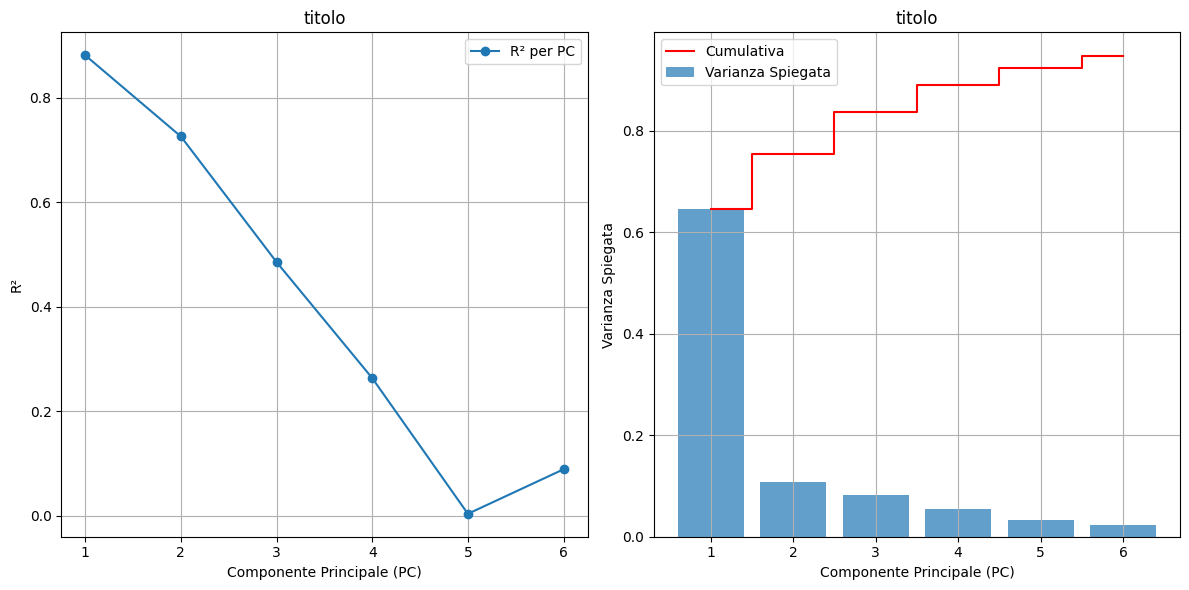

In [79]:
# Combina gli embedding originali di Z1 e Z3
original_embeddings_combined = np.hstack([original_y2_1, original_y2_2])
# Combina gli embedding ricostruiti di Z1 e Z3
reconstructed_embeddings_combined = np.hstack([reconstructed_y2_1, reconstructed_y2_2])

r2_Z1Z3, ind4 = pca_r2_analysis_embeddings(original_embeddings_combined, reconstructed_embeddings_combined, n_components=6)

In [80]:
output_path = "Decoder Analysis Data"
output_path += f"/{decoder_name}"
output_path += ".csv"

print (output_path)

save_decoder_analysis_data(model_name=decoder_name, 
                   latent_dim = decoder_config["latent_dim"], 
                   r2_mean1 = mean_r21, r2_std1 = std_r21, 
                   mse_mean1 = mean_mse, mse_std1 = std_mse, 
                   maxse_mean1 = mean_max_se, maxse_std1 = std_max_se,
                   r2_mean2 = mean_r22, r2_std2 = std_r22,
                   mse_mean2 = mean_mse2, mse_std2 = std_mse2,
                   maxse_mean2 = mean_max_se2, maxse_std2 = std_max_se2,
                   r2_z1 = r2_z1, r2_z2 = r2_z2,r2_Z1Z3 = r2_Z1Z3,
                   r2_t_Z1=r2_1, r2_t_Z3=r2_2,
                   ind1= ind2, ind2=ind3, ind3=ind4,
                   file_path=output_path)

Decoder Analysis Data/PaperVAE22.csv
Analysis data saved to Decoder Analysis Data/PaperVAE22.csv
